# Step 2: Strategy Design
In this notebook, we are moving from simply looking at data, to applying mathematical rules to it. We will build a **Moving Average Crossover** algorithm.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Get the Data
Going back 5 years to give our 200-day moving average plenty of data to calculate.

In [2]:
ticker = "SPY"
df = yf.Ticker(ticker).history(start="2019-01-01", end="2024-01-01")
df = df[['Close']].copy()  # Only keep the Close column for simplicity


## 2. Moving Average Calculations
We use `.rolling(window=X).mean()` to automatically calculate the average price over the last X days.

In [3]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Drop the first 200 days which show 'NaN' because they don't have enough history to make an average
df.dropna(inplace=True)
df.head()

,Close,SMA_50,SMA_200
Date,,,
2019-10-16 00:00:00-04:00,271.363922,266.526179,257.775196
2019-10-17 00:00:00-04:00,272.164154,266.755959,258.014104
2019-10-18 00:00:00-04:00,270.972870,266.859626,258.273828
2019-10-21 00:00:00-04:00,272.809906,267.036241,258.506054
2019-10-22 00:00:00-04:00,271.918762,267.259304,258.724901


## 3. Signal Generation (The Algorithm)
Here we create the logic: Hold (1) when 50-day is higher than 200-day. Sell/Wait (0) when it's lower.

In [4]:
# Create the rule: 1 means Hold, 0 means Don't Hold
df['Signal'] = np.where(df['SMA_50'] > df['SMA_200'], 1, 0)

# The 'Position' column will calculate the difference from the previous day.
# 1 - 0 = 1 (A Buy trigger!)
# 0 - 1 = -1 (A Sell trigger!)
# 1 - 1 = 0 (Just holding, no action needed)
df['Position'] = df['Signal'].diff()

df.tail()

,Close,SMA_50,SMA_200,Signal,Position
Date,,,,,
2023-12-22 00:00:00-05:00,460.964386,432.433622,417.883859,1,0.0
2023-12-26 00:00:00-05:00,462.910889,433.326888,418.348656,1,0.0
2023-12-27 00:00:00-05:00,463.747833,434.148882,418.820273,1,0.0
2023-12-28 00:00:00-05:00,463.923004,434.974768,419.262234,1,0.0
2023-12-29 00:00:00-05:00,462.579956,435.886423,419.709222,1,0.0


## 4. Visualizing the Strategy
Let's plot everything together so we can actually see the crossover triggers happen.

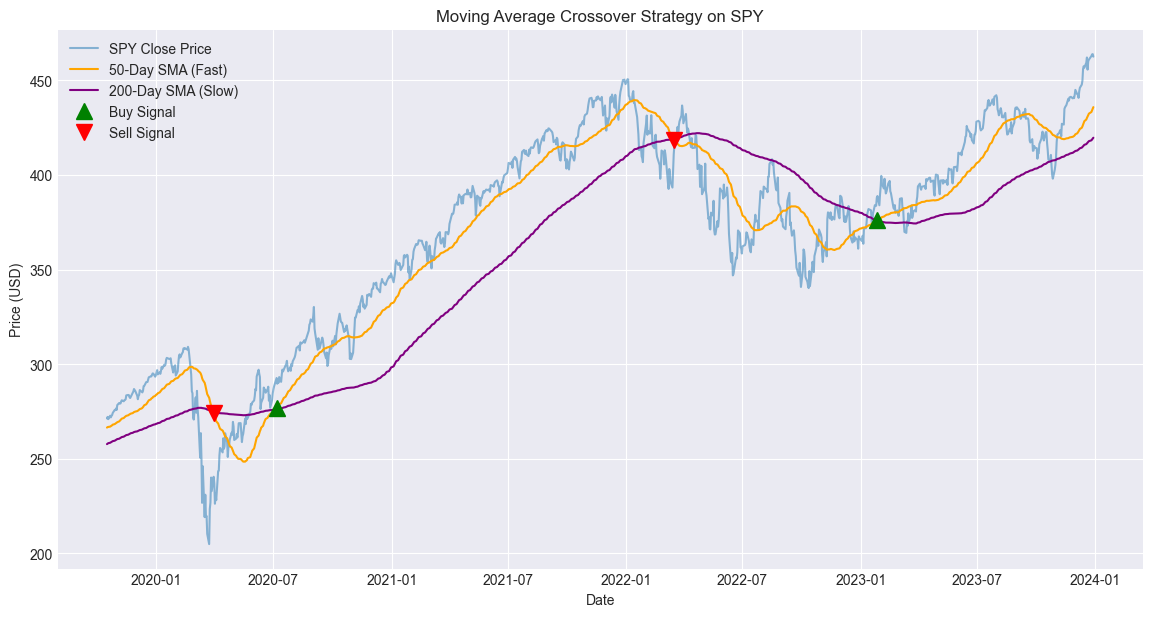

In [5]:
plt.figure(figsize=(14, 7))

# Plot the core lines
plt.plot(df.index, df['Close'], label='SPY Close Price', alpha=0.5)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA (Fast)', color='orange')
plt.plot(df.index, df['SMA_200'], label='200-Day SMA (Slow)', color='purple')

# Plot the BUY arrows (where Position == 1)
plt.plot(df[df['Position'] == 1].index, 
         df['SMA_50'][df['Position'] == 1], 
         '^', markersize=12, color='green', label='Buy Signal')

# Plot the SELL arrows (where Position == -1)
plt.plot(df[df['Position'] == -1].index, 
         df['SMA_50'][df['Position'] == -1], 
         'v', markersize=12, color='red', label='Sell Signal')

plt.title("Moving Average Crossover Strategy on SPY")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()